In [1]:
import pandas as pd
#Load the dataset
df = pd.read_csv('kidney_dataset.csv')

#Print the first 5 rows of the dataframe.
df.head()

,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,NaN,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,ACE Inhibitor,1
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,Diuretic,0
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,ACE Inhibitor,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,ARB,0


In [2]:
X = df.drop('CKD_Status',axis=1) 
y = df['CKD_Status'] 

In [3]:
from sklearn.tree import DecisionTreeClassifier


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [5]:
df = pd.read_csv('kidney_dataset.csv')

X = df.drop('CKD_Status', axis=1)
y = df['CKD_Status']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [7]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)


In [8]:
model = DecisionTreeClassifier()
model.fit(X_train_enc, y_train)


DecisionTreeClassifier()

In [9]:
y_pred = model.predict(X_test_enc)


In [10]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


In [11]:
y_pred = model.predict(X_test_enc)


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))


Accuracy: 1.0


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[1106    0]
 [   0  394]]


In [14]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       1.00      1.00      1.00       394

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       1.00      1.00      1.00       394

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



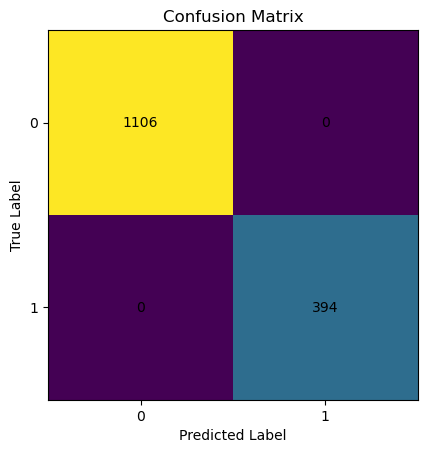

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# โหลดข้อมูล
df = pd.read_csv('kidney_dataset.csv')

# แยก X และ y
X = df.drop('CKD_Status', axis=1)
y = df['CKD_Status']

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# แยกประเภทคอลัมน์
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

# สร้าง encoder
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Encode
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train_enc, y_train)

# Predict
y_pred = model.predict(X_test_enc)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1])
plt.yticks([0, 1])

plt.show()


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred = model.predict(X_test_enc)

# 1️⃣ Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

# 2️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 3️⃣ Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
[[1106    0]
 [   0  394]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       1.00      1.00      1.00       394

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [18]:
from sklearn.metrics import roc_auc_score

# ต้องใช้ predict_proba
y_prob = model.predict_proba(X_test_enc)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("AUC =", auc)


AUC = 1.0
